In [2]:

import pickle
import numpy as np

# posterior estimates (includes means, stds, AND all actual samples)
with open('../data/processed/pymc_posterior_estimates.pkl', 'rb') as f:
    pymc_results = pickle.load(f)

# Summary statistics
beta_mean = pymc_results['beta_mean']
beta_std = pymc_results['beta_std']
intercept_mean = pymc_results['intercept_mean']
intercept_std = pymc_results['intercept_std']

# ALL actual posterior samples (all draws from all chains)
beta_all_samples = pymc_results['beta_all_samples']  # Shape: (n_chains * n_draws, n_features)
intercept_all_samples = pymc_results['intercept_all_samples']  # Shape: (n_chains * n_draws,)

feature_names = pymc_results['feature_names']
n_chains = pymc_results['n_chains']
n_draws = pymc_results['n_draws']

print("Loaded posterior estimates:")
print(f"Beta mean shape: {beta_mean.shape}")
print(f"Beta ALL samples shape: {beta_all_samples.shape} ({n_chains} chains × {n_draws} draws)")
print(f"Intercept ALL samples shape: {intercept_all_samples.shape}")
print(f"Intercept mean: {intercept_mean:.4f}")
print(f"Number of features: {len(feature_names)}")
print(f"\nExample: Access all beta values for feature 0:")
print(f"  beta_all_samples[:, 0] shape: {beta_all_samples[:, 0].shape}")
print(f"  First 5 values: {beta_all_samples[:5, 0]}")

# Load full trace if you need full trace object with chain/draw dimensions preserved
# with open('../data/processed/pymc_trace.pkl', 'rb') as f:
#     trace = pickle.load(f)

# Load summary statistics
# with open('../data/processed/pymc_summary.pkl', 'rb') as f:
#     summary = pickle.load(f)



Loaded posterior estimates:
Beta mean shape: (66,)
Beta ALL samples shape: (8000, 66) (4 chains × 2000 draws)
Intercept ALL samples shape: (8000,)
Intercept mean: -2.3202
Number of features: 66

Example: Access all beta values for feature 0:
  beta_all_samples[:, 0] shape: (8000,)
  First 5 values: [-0.67052419 -0.42008336 -0.54416408 -0.79388437 -0.59456074]


In [3]:
# Load validation data for temperature scaling
import pickle
import numpy as np
import pandas as pd

# Load validation features and targets (files are named X_vas, y_va but we use X_val, y_val as variables)
X_val = pd.DataFrame(np.load('../data/processed/X_vas.npy'))
y_val = np.load('../data/processed/y_va.npy')

# Load feature names to set columns
with open('../data/processed/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

X_val.columns = feature_names
X_val_array = X_val.to_numpy(dtype=np.float64)

print(f"Validation data loaded:")
print(f"X_val shape: {X_val_array.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"Class distribution: {np.bincount(y_val)}")

Validation data loaded:
X_val shape: (2322, 66)
y_val shape: (2322,)
Class distribution: [1941  381]


In [4]:
# Compute utilities/logits using posterior mean parameters
# For binary classification: U_i,0 = 0, U_i,1 = η_i = intercept + X_i^T β
# Using sigmoid directly (equivalent to softmax with 2 classes where U_0=0)

eta_val = intercept_mean + X_val_array @ beta_mean  # Shape: (n_samples,)

# For softmax formulation: logits = [0, η_i] for each sample
# But since we're using sigmoid, we can work directly with η_i
logits_val = eta_val

print(f"Logits computed:")
print(f"Logits (η) shape: {logits_val.shape}")
print(f"Logits range: [{logits_val.min():.4f}, {logits_val.max():.4f}]")
print(f"Logits mean: {logits_val.mean():.4f}")


Logits computed:
Logits (η) shape: (2322,)
Logits range: [-6.6578, 28.3033]
Logits mean: -2.1528


In [5]:
# Negative Log-Likelihood function
# We minimize NLL (equivalently maximize log-likelihood) on validation data
# Correct formulation: P(y_i=1 | x_i) = σ(λ * η_i) where λ is rationality/inverse temperature

def negative_log_likelihood(lambda_rationality, logits, y_true):
    """
    Compute negative log-likelihood for rationality-scaled binary classification.
    Using sigmoid: p = σ(λ * η_i) where λ is rationality parameter (inverse temperature)
    
    Log-likelihood: ℓ(λ) = Σ[λ y_i η_i - log(1 + exp(λ η_i))]
    NLL(λ) = -ℓ(λ) = Σ[log(1 + exp(λ η_i)) - λ y_i η_i]
    
    Args:
        lambda_rationality: Rationality parameter λ (inverse temperature, must be > 0)
        logits: Raw logits η_i = intercept + X^T β (shape: n_samples,)
        y_true: True binary labels (shape: n_samples,)
    
    Returns:
        Negative log-likelihood (scalar)
    """
    # Enforce λ > 0
    lambda_rationality = max(lambda_rationality, 1e-8)
    
    # Scale logits by rationality: z = λ * η_i
    z = lambda_rationality * logits
    
    # Numerically stable computation of log(1 + exp(z))
    # Use logaddexp(0, z) = log(1 + exp(z)) for stability
    log1p_exp_z = np.logaddexp(0, z)
    
    # NLL(λ) = Σ[log(1 + exp(λ η_i)) - λ y_i η_i]
    nll = np.sum(log1p_exp_z - lambda_rationality * y_true * logits)
    
    return nll



In [6]:
# Gradient of Negative Log-Likelihood
# For NLL(λ) = Σ[log(1 + exp(λ η_i)) - λ y_i η_i]

def gradient_nll(lambda_rationality, logits, y_true):
    """
    Compute gradient of NLL w.r.t. λ.
    
    d/dλ NLL(λ) = d/dλ Σ[log(1 + exp(λ η_i)) - λ y_i η_i]
                 = Σ[(exp(λ η_i) / (1 + exp(λ η_i))) * η_i - y_i η_i]
                 = Σ[(p_i - y_i) * η_i]
    
    where p_i = σ(λ η_i) = exp(λ η_i) / (1 + exp(λ η_i))
    
    Args:
        lambda_rationality: Rationality parameter λ (must be > 0)
        logits: Raw logits η_i (shape: n_samples,)
        y_true: True binary labels (shape: n_samples,)
    
    Returns:
        Gradient of NLL w.r.t. λ (scalar)
    """
    # Enforce λ > 0
    lambda_rationality = max(lambda_rationality, 1e-8)
    
    # Scale logits: z = λ * η_i
    z = lambda_rationality * logits
    
    # Numerically stable sigmoid: p = σ(z) = 1 / (1 + exp(-z))
    # For large negative z, use: p = exp(z) / (1 + exp(z))
    # Use logaddexp trick for stability
    p = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    
    # Gradient: d/dλ NLL = Σ[(p_i - y_i) * η_i]
    grad = np.sum((p - y_true) * logits)
    
    return grad


In [7]:
# Hessian of Negative Log-Likelihood
# For NLL(λ) = Σ[log(1 + exp(λ η_i)) - λ y_i η_i]

def hessian_nll(lambda_rationality, logits, y_true):
    """
    Compute Hessian (second derivative) of NLL w.r.t. λ.
    
    d²/dλ² NLL(λ) = d/dλ Σ[(p_i - y_i) * η_i]
                   = Σ[d/dλ p_i * η_i]
                   = Σ[p_i(1-p_i) * η_i²]
    
    where p_i = σ(λ η_i), so d/dλ p_i = p_i(1-p_i) * η_i
    
    Note: This is always ≥ 0, ensuring convexity.
    
    Args:
        lambda_rationality: Rationality parameter λ (must be > 0)
        logits: Raw logits η_i (shape: n_samples,)
        y_true: True binary labels (shape: n_samples,)
    
    Returns:
        Hessian of NLL w.r.t. λ (scalar, should be ≥ 0)
    """
    # Enforce λ > 0
    lambda_rationality = max(lambda_rationality, 1e-8)
    
    # Scale logits: z = λ * η_i
    z = lambda_rationality * logits
    
    # Numerically stable sigmoid: p = σ(z)
    p = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    
    # Hessian: d²/dλ² NLL = Σ[p_i(1-p_i) * η_i²]
    hess = np.sum(p * (1 - p) * logits ** 2)
    
    return hess


In [8]:
# Newton's Method for Rationality Parameter Optimization

def newton_method_temperature(logits, y_true, lambda_init=1.0, tol=1e-6, max_iter=100):
    """
    Find optimal rationality parameter λ using Newton's method to minimize NLL.
    
    Newton update: λ_new = λ_old - grad / hess
    
    Args:
        logits: Raw logits η_i from model (shape: n_samples,)
        y_true: True binary labels (shape: n_samples,)
        lambda_init: Initial guess for λ (default: 1.0)
        tol: Convergence tolerance
        max_iter: Maximum iterations
    
    Returns:
        lambda_hat: Optimal rationality parameter
        history: Dictionary with optimization history
    """
    lambda_curr = max(lambda_init, 1e-8)  # Ensure positive
    history = {'lambda': [lambda_curr], 'nll': [], 'grad': [], 'hess': []}
    
    for i in range(max_iter):
        # Compute objective, gradient, and hessian
        nll = negative_log_likelihood(lambda_curr, logits, y_true)
        grad = gradient_nll(lambda_curr, logits, y_true)
        hess = hessian_nll(lambda_curr, logits, y_true)
        
        history['nll'].append(nll)
        history['grad'].append(grad)
        history['hess'].append(hess)
        
        # Print iteration diagnostics
        print(f"Iter {i+1:3d}: λ={lambda_curr:.6f}, NLL={nll:.6f}, grad={grad:.6e}, hess={hess:.6e}")
        
        # Check convergence
        if abs(grad) < tol:
            print(f"\nConverged after {i+1} iterations")
            break
        
        # Newton step: λ_new = λ_old - grad / hess
        # With damping: if step increases NLL, halve step size
        if hess > 1e-10:  # Hessian should be positive (convex)
            step = grad / hess
            lambda_new = lambda_curr - step
            
            # Enforce λ > 0
            lambda_new = max(lambda_new, 1e-8)
            
            # Check if step increases NLL (damping)
            nll_new = negative_log_likelihood(lambda_new, logits, y_true)
            damping_factor = 1.0
            max_damping_iter = 10
            
            while nll_new > nll and damping_factor > 1e-6 and max_damping_iter > 0:
                damping_factor *= 0.5
                lambda_new = lambda_curr - damping_factor * step
                lambda_new = max(lambda_new, 1e-8)
                nll_new = negative_log_likelihood(lambda_new, logits, y_true)
                max_damping_iter -= 1
            
            lambda_curr = lambda_new
        else:
            # If hessian is too small, use small gradient descent step
            print(f"  Warning: Hessian too small ({hess:.2e}), using small gradient step")
            lambda_curr = max(lambda_curr - 0.01 * grad, 1e-8)
        
        history['lambda'].append(lambda_curr)
    
    return lambda_curr, history


In [9]:
# Grid check: Evaluate NLL over a range of λ values to confirm Newton solution
print("Grid check: Evaluating NLL over λ ∈ [0.05, 5.0]...")
lambda_grid = np.linspace(0.05, 5.0, 100)
nll_grid = np.array([negative_log_likelihood(lam, logits_val, y_val) for lam in lambda_grid])
lambda_grid_min = lambda_grid[np.argmin(nll_grid)]

print(f"Grid minimum: λ = {lambda_grid_min:.6f}, NLL = {np.min(nll_grid):.6f}")

# Run Newton's method to find optimal rationality parameter
print("\n" + "="*60)
print("Finding optimal rationality parameter λ using Newton's method...")
print("="*60)
lambda_hat, history = newton_method_temperature(logits_val, y_val, lambda_init=1.0)

print(f"\n{'='*60}")
print(f"Results:")
print(f"{'='*60}")
print(f"Optimal rationality parameter λ̂ = {lambda_hat:.6f}")
print(f"Final negative log-likelihood: {history['nll'][-1]:.6f}")
print(f"Final gradient: {history['grad'][-1]:.6e}")
print(f"Final hessian: {history['hess'][-1]:.6e}")
print(f"\nGrid check comparison:")
print(f"  Grid minimum λ: {lambda_grid_min:.6f}")
print(f"  Newton λ̂:        {lambda_hat:.6f}")
print(f"  Difference:      {abs(lambda_hat - lambda_grid_min):.6f}")


Grid check: Evaluating NLL over λ ∈ [0.05, 5.0]...
Grid minimum: λ = 0.950000, NLL = 717.290433

Finding optimal rationality parameter λ using Newton's method...
Iter   1: λ=1.000000, NLL=717.346450, grad=2.120914e+01, hess=7.740293e+02
Iter   2: λ=0.972599, NLL=717.061867, grad=-6.596421e-01, hess=8.226997e+02
Iter   3: λ=0.973401, NLL=717.061602, grad=-5.891826e-04, hess=8.212305e+02
Iter   4: λ=0.973402, NLL=717.061602, grad=-4.711040e-10, hess=8.212292e+02

Converged after 4 iterations

Results:
Optimal rationality parameter λ̂ = 0.973402
Final negative log-likelihood: 717.061602
Final gradient: -4.711040e-10
Final hessian: 8.212292e+02

Grid check comparison:
  Grid minimum λ: 0.950000
  Newton λ̂:        0.973402
  Difference:      0.023402


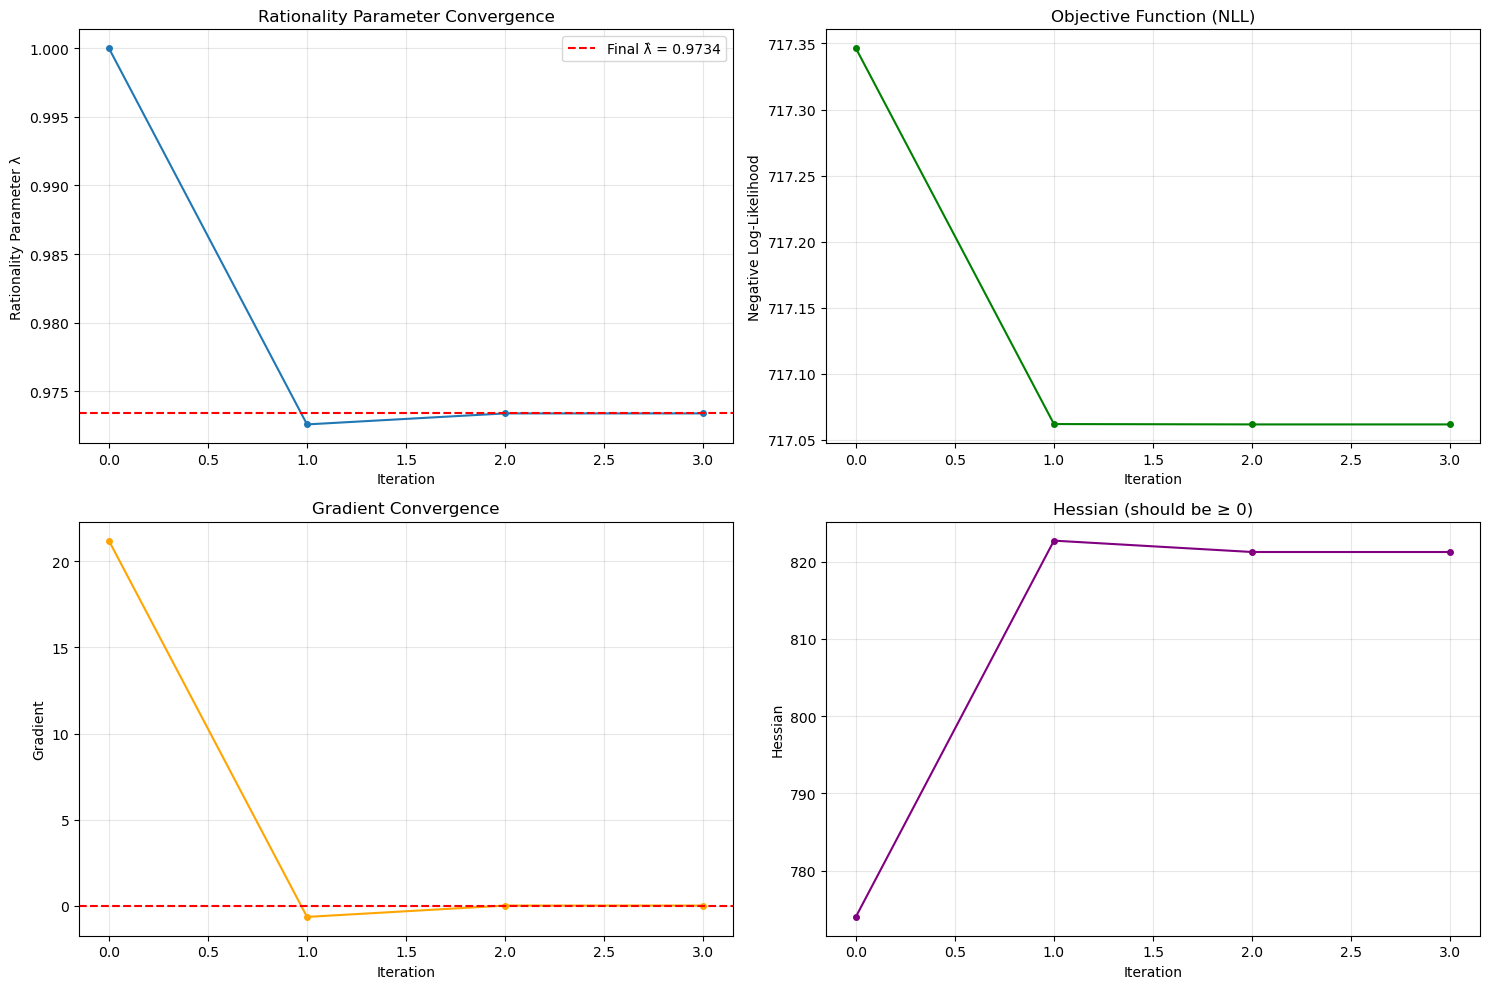

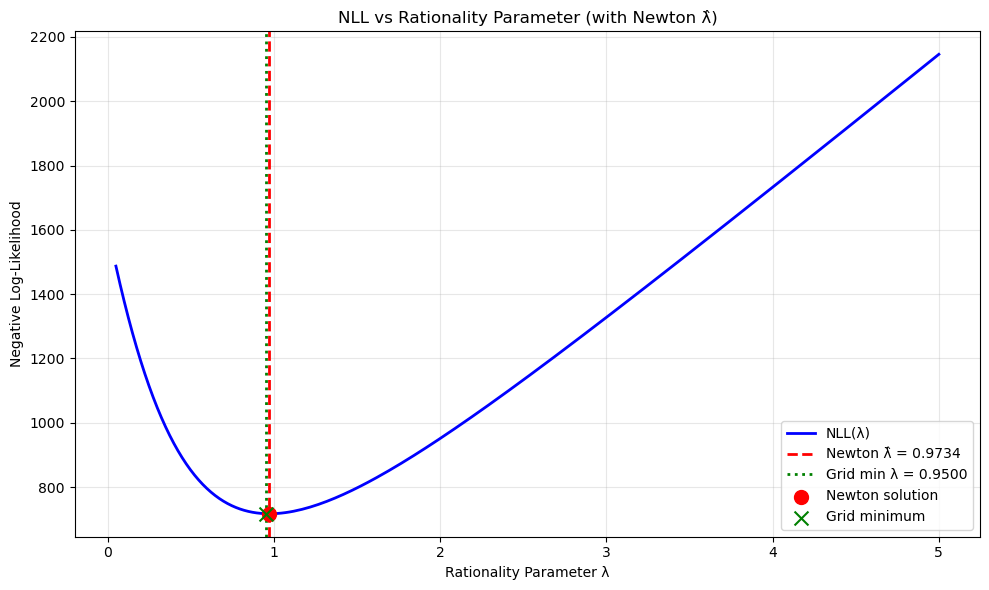


Optimization Summary:
  Initial λ: 1.000000
  Final λ̂: 0.973402
  Change: -0.026598
  Iterations: 4
  Final NLL: 717.061602
  Grid minimum NLL: 717.290433
  NLL difference: 2.288307e-01


In [10]:
# Visualize optimization progress
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Lambda convergence
axes[0, 0].plot(history['lambda'], marker='o', markersize=4)
axes[0, 0].axhline(y=lambda_hat, color='r', linestyle='--', label=f'Final λ̂ = {lambda_hat:.4f}')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Rationality Parameter λ')
axes[0, 0].set_title('Rationality Parameter Convergence')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Negative log-likelihood
axes[0, 1].plot(history['nll'], marker='o', markersize=4, color='green')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Negative Log-Likelihood')
axes[0, 1].set_title('Objective Function (NLL)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Gradient
axes[1, 0].plot(history['grad'], marker='o', markersize=4, color='orange')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Gradient')
axes[1, 0].set_title('Gradient Convergence')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Hessian
axes[1, 1].plot(history['hess'], marker='o', markersize=4, color='purple')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Hessian')
axes[1, 1].set_title('Hessian (should be ≥ 0)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot NLL vs λ on a grid (sanity check)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
lambda_grid_plot = np.linspace(0.05, 5.0, 200)
nll_grid_plot = np.array([negative_log_likelihood(lam, logits_val, y_val) for lam in lambda_grid_plot])
ax.plot(lambda_grid_plot, nll_grid_plot, 'b-', linewidth=2, label='NLL(λ)')
ax.axvline(x=lambda_hat, color='r', linestyle='--', linewidth=2, label=f'Newton λ̂ = {lambda_hat:.4f}')
ax.axvline(x=lambda_grid_min, color='g', linestyle=':', linewidth=2, label=f'Grid min λ = {lambda_grid_min:.4f}')
ax.scatter([lambda_hat], [history['nll'][-1]], color='red', s=100, zorder=5, label='Newton solution')
ax.scatter([lambda_grid_min], [np.min(nll_grid)], color='green', s=100, zorder=5, marker='x', label='Grid minimum')
ax.set_xlabel('Rationality Parameter λ')
ax.set_ylabel('Negative Log-Likelihood')
ax.set_title('NLL vs Rationality Parameter (with Newton λ̂)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimization Summary:")
print(f"  Initial λ: {history['lambda'][0]:.6f}")
print(f"  Final λ̂: {lambda_hat:.6f}")
print(f"  Change: {lambda_hat - history['lambda'][0]:.6f}")
print(f"  Iterations: {len(history['nll'])}")
print(f"  Final NLL: {history['nll'][-1]:.6f}")
print(f"  Grid minimum NLL: {np.min(nll_grid):.6f}")
print(f"  NLL difference: {abs(history['nll'][-1] - np.min(nll_grid)):.6e}")



In [11]:
# Compare calibrated vs uncalibrated predictions
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

# Uncalibrated predictions (λ = 1.0): p = σ(1.0 * η_i) = σ(η_i)
p_uncalibrated = 1.0 / (1.0 + np.exp(-logits_val))

# Calibrated predictions (using optimal λ̂): p = σ(λ̂ * η_i)
p_calibrated = 1.0 / (1.0 + np.exp(-lambda_hat * logits_val))

# Compute metrics
print("Calibration Comparison:")
print(f"\nUncalibrated (λ = 1.0):")
print(f"  Log Loss: {log_loss(y_val, p_uncalibrated):.6f}")
print(f"  Brier Score: {brier_score_loss(y_val, p_uncalibrated):.6f}")
print(f"  AUC: {roc_auc_score(y_val, p_uncalibrated):.6f}")

print(f"\nCalibrated (λ̂ = {lambda_hat:.6f}):")
print(f"  Log Loss: {log_loss(y_val, p_calibrated):.6f}")
print(f"  Brier Score: {brier_score_loss(y_val, p_calibrated):.6f}")
print(f"  AUC: {roc_auc_score(y_val, p_calibrated):.6f}")

print(f"\nImprovement:")
print(f"  Log Loss reduction: {log_loss(y_val, p_uncalibrated) - log_loss(y_val, p_calibrated):.6f}")
print(f"  Brier Score reduction: {brier_score_loss(y_val, p_uncalibrated) - brier_score_loss(y_val, p_calibrated):.6f}")

# Interpretation
if lambda_hat > 1.0:
    print(f"\nInterpretation: λ̂ > 1 means the model was overconfident (too sharp).")
    print(f"  Temperature scaling makes predictions more conservative.")
elif lambda_hat < 1.0:
    print(f"\nInterpretation: λ̂ < 1 means the model was underconfident (too flat).")
    print(f"  Temperature scaling makes predictions sharper.")
else:
    print(f"\nInterpretation: λ̂ ≈ 1 means the model was well-calibrated.")



Calibration Comparison:

Uncalibrated (λ = 1.0):
  Log Loss: 0.308935
  Brier Score: 0.091417
  AUC: 0.884299

Calibrated (λ̂ = 0.973402):
  Log Loss: 0.308812
  Brier Score: 0.091322
  AUC: 0.884299

Improvement:
  Log Loss reduction: 0.000123
  Brier Score reduction: 0.000095

Interpretation: λ̂ < 1 means the model was underconfident (too flat).
  Temperature scaling makes predictions sharper.


In [12]:
# Save rationality temperature and calibration results
import os

os.makedirs('../data/processed', exist_ok=True)

rationality_results = {
    'lambda_hat': lambda_hat,
    'optimization_history': history,
    'logits_validation': logits_val,
    'p_calibrated': p_calibrated,
    'p_uncalibrated': p_uncalibrated,
    'metrics': {
        'log_loss_uncalibrated': log_loss(y_val, p_uncalibrated),
        'log_loss_calibrated': log_loss(y_val, p_calibrated),
        'brier_uncalibrated': brier_score_loss(y_val, p_uncalibrated),
        'brier_calibrated': brier_score_loss(y_val, p_calibrated),
        'auc_uncalibrated': roc_auc_score(y_val, p_uncalibrated),
        'auc_calibrated': roc_auc_score(y_val, p_calibrated)
    }
}

with open('../data/processed/rationality_temperature.pkl', 'wb') as f:
    pickle.dump(rationality_results, f)

print("Rationality temperature results saved!")
print(f"  Saved to: ../data/processed/rationality_temperature.pkl")
print(f"  Contains: λ̂, optimization history, calibrated predictions, and metrics")



Rationality temperature results saved!
  Saved to: ../data/processed/rationality_temperature.pkl
  Contains: λ̂, optimization history, calibrated predictions, and metrics


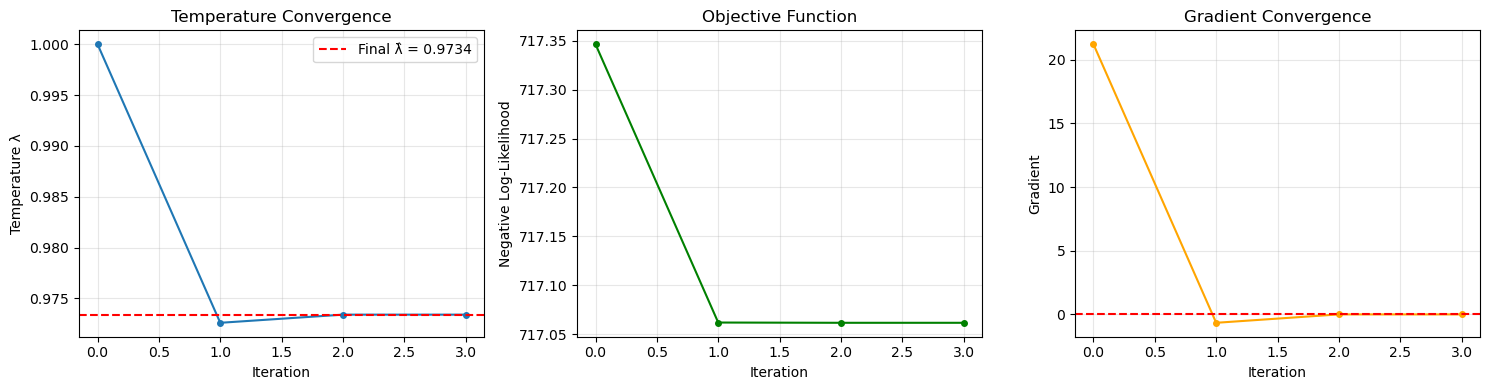


Optimization Summary:
  Initial λ: 1.000000
  Final λ̂: 0.973402
  Change: -0.026598
  Iterations: 4
  Final NLL: 717.0616


In [13]:
# Visualize optimization progress
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Lambda convergence
axes[0].plot(history['lambda'], marker='o', markersize=4)
axes[0].axhline(y=lambda_hat, color='r', linestyle='--', label=f'Final λ̂ = {lambda_hat:.4f}')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Temperature λ')
axes[0].set_title('Temperature Convergence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Negative log-likelihood
axes[1].plot(history['nll'], marker='o', markersize=4, color='green')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Negative Log-Likelihood')
axes[1].set_title('Objective Function')
axes[1].grid(True, alpha=0.3)

# Plot 3: Gradient
axes[2].plot(history['grad'], marker='o', markersize=4, color='orange')
axes[2].axhline(y=0, color='r', linestyle='--')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Gradient')
axes[2].set_title('Gradient Convergence')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimization Summary:")
print(f"  Initial λ: {history['lambda'][0]:.6f}")
print(f"  Final λ̂: {lambda_hat:.6f}")
print(f"  Change: {lambda_hat - history['lambda'][0]:.6f}")
print(f"  Iterations: {len(history['nll'])}")
print(f"  Final NLL: {history['nll'][-1]:.4f}")



In [14]:
import os

os.makedirs('../data/processed', exist_ok=True)

rationality_results = {
    'lambda_hat': lambda_hat,
    'optimization_history': history,
    'logits_validation': logits_va,
    'p_calibrated': p_calibrated,
    'p_uncalibrated': p_uncalibrated,
    'metrics': {
        'log_loss_uncalibrated': log_loss(y_va, p_uncalibrated),
        'log_loss_calibrated': log_loss(y_va, p_calibrated),
        'brier_uncalibrated': brier_score_loss(y_va, p_uncalibrated),
        'brier_calibrated': brier_score_loss(y_va, p_calibrated),
        'auc_uncalibrated': roc_auc_score(y_va, p_uncalibrated),
        'auc_calibrated': roc_auc_score(y_va, p_calibrated)
    }
}

with open('../data/processed/rationality_temperature.pkl', 'wb') as f:
    pickle.dump(rationality_results, f)

print("Rationality temperature results saved!")
print(f"  Saved to: ../data/processed/rationality_temperature.pkl")
print(f"  Contains: λ̂, optimization history, calibrated predictions, and metrics")



NameError: name 'logits_va' is not defined